# Thermodynamic parameter Plots for Schofield Paper

Can we obtain the same values reported by Scholfield? I hope so. And we can dosument the math so that others can follow our steps exactly.

I'm also going to try to make a program that will automate making all the Erying plots from the collection in the data set. Can I deterct how many substituents have data for an Erying plot and then plot separate the data? I'll have to learn some things. I enjoy learning new things. Lets go!

## isokinetic Plot

Using the notebook 'Fig_12_14_EyringPlot.ipynb' we obtained and plotted the Eyring plots. Values for $\Delta H^\ddagger$ and $\Delta S^\ddagger$ and the stdevs were collected in a csv file.

### Data

The data is collected in a file: "output/Table_4_from_Fig_12_Eyring_dH_dS.csv"


### The isokinetic Plot

I will create an Isokinetic plot. The slope is the isokinetic temp. I will plot error bars and use an orthogonal fitting algorithm to include the horizontal error bars in the fit/ 

(1) "Kinetics and mechanism of the Beckmann rearrangement of acetophenone oximes in sulphuric acid." Gregory, B. J., Moodie, R. B., & Schofield, K., *Journal of the Chemical Society B: Physical Organic*, **1970**, 338-346. https://doi.org/10.1039/j29700000338 


In [9]:
# Generic Setup
# Imports and file locations
# 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import uncertainties as unc
from uncertainties import unumpy as unp
import lmfit

github = False

if github == True:
    github_location = "https://raw.githubusercontent.com/blinkletter/4410PythonNotebooks/main/Class_21/data/"
    github_location_styles = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/styles/"
    github_location_LFER_tables = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/data/"
else:  
    github_location = "data/"
    github_location_styles = "../../styles/"
    github_location_LFER_tables = "~/github/LFER-QSAR/data/"

style_file = "tufte.mplstyle"
#style_file = "S2_classic2.mplstyle"

# Set plot style for all plots

plt.style.use(github_location_styles + style_file)  


In [10]:
# Load data from CSV file from previous notebook - see 'Fig_12_14_EyringPlot.ipynb'
df = pd.read_csv('output/Table_4_from_Fig_12_Eyring_dH_dS.csv')
df

,Substituent,%H2SO4,dH_kJmol,dH_err_kJmol,dS_JmolK,dS_err_JmolK
0,H,98.2,108.500687,1.557544,8.208486,4.480708
1,H,91.7,110.084696,1.089298,-2.903372,3.091963
2,H,79.3,120.791480,0.360092,11.048523,1.006895
3,p-Br,98.2,113.677999,0.000000,19.453656,0.000000
4,p-CH3,98.2,106.359091,3.768080,6.433959,11.403428
5,p-Cl,98.2,107.896860,3.615587,2.565824,10.355772
6,p-F,98.2,114.212517,0.000000,22.339701,0.000000
7,p-I,98.2,109.367260,0.000000,7.662905,0.000000
8,p-NO2,98.2,123.200239,6.024384,24.137021,17.255056
9,p-OCH3,85.8,113.767934,4.157190,6.466478,11.624398


In [11]:
# get list of unique values in Substituent column
substituents = df['Substituent'].unique()
substituents.sort()
substituent_list = substituents.tolist()
substituent_list



['H', 'p-Br', 'p-CH3', 'p-Cl', 'p-F', 'p-I', 'p-NO2', 'p-OCH3']

In [12]:
## Create a dictionary. Substituent as key, list of concentrations as values. 
## Only include concentrations that appear more than once.
## Then remove any items with empty lists.

# for each substituent get list of unique values in %H2SO4 column and put in a dictionary
concs = {}
for substituent in substituent_list:
    #print(substituent)
    sss = df.loc[df['Substituent'] == substituent, '%H2SO4']
    # remove all values in sss that appear only once
    #sss = sss[sss.duplicated(keep=False)]
    #print(sss)

    concs[substituent] = sss.tolist()

# remove empty dictionary items
concs = {k: v for k, v in concs.items() if v}
print(concs)


{'H': [98.2, 91.7, 79.3], 'p-Br': [98.2], 'p-CH3': [98.2], 'p-Cl': [98.2], 'p-F': [98.2], 'p-I': [98.2], 'p-NO2': [98.2], 'p-OCH3': [85.8]}



ODR Linear Fit Results:
Slope (m): 859.4014
Intercept (c): 101988.7962

Optional: Display the full results summary
Beta: [   859.40137452 101988.79616884]
Beta Std Error: [ 274.77207966 2439.46861367]
Beta Covariance: [[  845018.22521997 -6778550.26503193]
 [-6778550.26503193 66605691.8735547 ]]
Residual Variance: 0.08934682531897516
Inverse Condition #: 0.004800554051380174
Reason(s) for Halting:
  Sum of squares convergence

LEAST SQUARES scipy.optimize.curve_fit
slope: 797.9177917473536, intercept: 103241.68324780013
slope stdev: 155.11484825957208, intercept stdev: 2048.975959653341
(103241.68324780013+/-2048.975959653341, 797.9177917473536+/-155.11484825957208)
[103241.6832478     797.91779175]
[[4198302.48323733 -248698.28955708]
 [-248698.28955708   24060.61615059]]


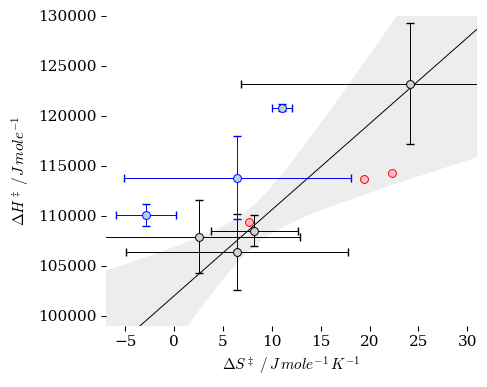

In [13]:
# Make isokinetic plot

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

# empty lists to collect data for linear regression. Only for specific substituents and concentration of 98.2%
x_line = []
y_line = []
x_line_err = []
y_line_err = []

for substituent in substituent_list:
    scs = list(set(concs[substituent]))
    for c in scs:
        df_temp = df.loc[(df['Substituent'] == substituent) & (df['%H2SO4'] == c), : ]

        x = df_temp['dS_JmolK']   # x is entropy in Joules
        y = df_temp['dH_kJmol'] * 1000  # y is enthalpy in Joules          # y is ln(k_obs)
        x_err = df_temp['dS_err_JmolK']   # x is entropy in Joules
        y_err = df_temp['dH_err_kJmol'] * 1000  # y is enthalpy in Joules          # y is ln(k_obs)

        if c == 98.2 and substituent in ['p-Br', 'p-I', 'p-F']:
            ax.scatter(x,y, s = 32, color="pink",  edgecolors = "red", zorder=2, linewidths=0.7)
            ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='none', ecolor='red', color='red', elinewidth=0.7, capsize=3, zorder=1)
        elif c == 98.2 and substituent in ['H', 'p-CH3', 'p-Cl', 'p-NO2']:
            ax.scatter(x,y, s = 32, color="lightgray",  edgecolors = "black", zorder=4, linewidths=0.7)
            ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='none', ecolor='black', color='black', elinewidth=0.7, capsize=3, zorder=1, marker = None)
            # Here we collect just the data that fits this rule for linear regression later
            y_line.append(y)
            x_line.append(x)
            y_line_err.append(y_err)
            x_line_err.append(x_err)
        else:
            ax.scatter(x,y, s = 32, color="lightblue",  edgecolors = "blue", zorder=2, linewidths=0.7)
            ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='none', ecolor='blue', color='blue', elinewidth=0.7, capsize=3, zorder=1)

# Data to be used for linear fit.
x_line = np.array(x_line).flatten() # flatten lists of arrays into single arrays
y_line = np.array(y_line).flatten()
x_line_err = np.array(x_line_err).flatten()
y_line_err = np.array(y_line_err).flatten()
#print(x_line, y_line, x_line_err, y_line_err)

################################################
### Orthogonal Distance Regression (ODR) using scipy.odr
################################################

# code stolen from Google search AI example for ODR
import numpy as np
import matplotlib.pyplot as plt
import scipy

# 1. Define the linear function to fit
def linear_func(p, x):
    """Linear function y = mx + c"""
    m, c = p
    return m * x + c

# 2. Generate some example data with errors
x = x_line
y = y_line
# Define your horizontal (x) and vertical (y) errors
x_err = x_line_err
y_err = y_line_err

# 3. Create a Model, RealData, and ODR object
# 'f' is the function, 'ifixb' specifies which parameters are fixed (if any)
linear_model = scipy.odr.Model(linear_func)
# RealData takes x data, y data, and their respective errors (sx for x, sy for y)
data = scipy.odr.RealData(x, y, sx=x_err, sy=y_err)

# Set up ODR with the data and model, providing initial parameter estimates (beta0)
odr_instance = scipy.odr.ODR(data, linear_model, beta0=[1., 0.]) # Initial guess for m and c

# 4. Run the regression
output = odr_instance.run()

# 5. Get the results and print them
# output.beta contains the optimized parameters (m, c)
slope_odr, intercept_odr = output.beta
print(f"\nODR Linear Fit Results:")
print(f"Slope (m): {slope_odr:.4f}")
print(f"Intercept (c): {intercept_odr:.4f}")

print("\nOptional: Display the full results summary")
output.pprint()
##################################################
##################################################

# plot linear regression line
x_fit = np.linspace(x_line.min(), x_line.max(), 100)
x_fit = np.linspace(-10, 50, 100)
#x_fit = np.linspace(0, 0.00322, 100)
y_fit = slope_odr * x_fit + intercept_odr
ax.plot(x_fit, y_fit, '-', color='black', linewidth=0.7, zorder = 3)



ax.set_xlabel(r'$\Delta S^\ddagger \;/\, J\,mole^{-1}\,K^{-1}$')
ax.set_ylabel(r'$\Delta H^\ddagger \;/\, J\,mole^{-1}$')
#ax.set_xlim(0.0026, 0.0033)
ax.set_xlim(-7, 31)
ax.set_ylim(99000, 125000)
#ax.set_xticks([0.00265, 0.00285, 0.00305, 0.00325])
ax.set_yticks([100000, 105000, 110000, 115000, 120000, 125000, 130000])
#ax.set_title(f'Substituent: {substituent}, %H$_2$SO$_4$ = {c}') 

def linear_func(slope, int, x):
    """Linear function y = mx + c"""
    return slope * x + int

popt,pcov = scipy.optimize.curve_fit(linear_func, x_line, y_line, 
 #                                    sigma=y_line_err
                                     )
stderr = pcov.diagonal()**0.5

print('\nLEAST SQUARES scipy.optimize.curve_fit')
print(f'slope: {popt[1]}, intercept: {popt[0]}')
print(f'slope stdev: {stderr[1]}, intercept stdev: {stderr[0]}')
popt_un = unc.correlated_values(popt, pcov)
print(popt_un)
print(popt)
print(pcov)

def linear_func(p, x):
    """Linear function y = mx + c"""
    m, c = p
    return m * x + c

popt_un = unc.correlated_values(output.beta, output.cov_beta * output.res_var)

################################################################################
### Create Confidence band upper and lower bounds
################################################################################

sigma = 2

bestfit_y_fit = linear_func(popt_un, x_fit)
dev = unp.std_devs(bestfit_y_fit) * sigma

fit_up = unp.nominal_values(bestfit_y_fit) + dev
fit_dn = unp.nominal_values(bestfit_y_fit) - dev
ax.fill_between(x_fit, fit_up, fit_dn, 
                   color="lightgray", alpha=0.4, zorder = 0,
                   linewidth=0, label="confidence interval")


plt.savefig('plots/Fig_13_IsokineticPlot.pdf')
plt.show()